<a href="https://colab.research.google.com/github/wesleylelo/CDIA_AI_COLAB/blob/develop/HiperParametroRNA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
###################################################################
##################################################################
#Instituição: SENAI - CIMATEC
#Curso: Ciência de Dados e Inteligência Artificial (CDIA)
#Disciplina: Inteligência Artificial II
#Autor: Carlos Fernando Arraz | Data: Fevereiro, 2024
#UA04 - Roteiro de Prática Guiada 02: Hiperparametrização em RNA
###################################################################
###################################################################

---

INSTRUÇÕES GERAIS:

---



1 - Realize uma cópia deste arquivo em seu repositório pessoal para iniciar a prática (usar o e-mail institucional para isso);

2 - Reveja o conteúdo teórico e os exemplos práticos vistos até agora na graduação para pontecializar o aprendizado;

3 -Leia a teoria e acompanhe o script python linha a linha e seus comentários (execute as células com **shift + ENTER** ou botão play à esquerda de cada comando/bloco de código), estudando as estruturas, as partes do algoritmo e a lógica proposta;

4 - Execute, modifique, teste e experimente o conteúdo ao máximo para internalizar o conhecimento; e

5- Compare os resultados com bibliotecas de machine learning consagradas no desenvolvimento de soluções em AI.

#Este roteiro tem como objetivo mostrar um ciclo completo de terinamento de uma RNA e a busca dos melhores hiperparâmentros, tudo isso usando uma das mais modernas e consagradas bibliotecas para IA usadas, e, tudo isso, através de um script em python 🐍.


Este script está dividido em 6 partes, conforme itens a seguir:



1.   Parte I: Importar as dependências e criar uma rede neural artificial
2.   Parte II: Apresentar um problema de regressão com MultiLayer Perceptron (MLP)
3.   Parte III: Criar uma RNA mais robusta e complexa
4.   Parte IV: Salvar e carregar um modelo
5.   Parte V: Usar *Callbacks* durante o treinamento da RNA
6.   Parte VI:  Ajustar os hyperparâmetros






# Parte I: Importar as dependências e criar uma rede neural artificial adequado ao problema em questão.

Primeiro, vamos importar alguns módulos comuns, garantir que o MatplotLib desenhe as figuras inline. Também verificamos se o Python 3.5 ou posterior está instalado, bem como o Scikit-Learn ≥ 0,20 e o TensorFlow ≥ 2,0.

In [ ]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

try:
    # %tensorflow_version only exists in Colab.
    %tensorflow_version 2.x
except Exception:
    pass

# TensorFlow ≥2.0 is required
import tensorflow as tf
assert tf.__version__ >= "2.0"

# Common imports
import numpy as np
import os
import pandas as pd

#
import keras

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


#Parte II: Apresentar um problema de regressão com MultiLayer Perceptron (MLP)

Vamos carregar, dividir e dimensionar o famoso conjunto de dados habitacionais da Califórnia

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()

X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

In [ ]:
#Ver um exemplo de 1 observação
housing.data[0]

array([   8.3252    ,   41.        ,    6.98412698,    1.02380952,
        322.        ,    2.55555556,   37.88      , -122.23      ])

In [ ]:
#Ver um exemplo de 1 observação
X_train[0]

array([-0.19397883, -1.07781319, -0.94338545,  0.01485314,  0.02073335,
       -0.57291624,  0.92926047, -1.42215523])

In [ ]:
#Ver um exemplo de 1 observação
X_valid[0]

array([-0.72894678,  0.42524224, -0.72520018, -0.19686914,  1.42341277,
        0.76884409, -0.89312342,  0.86177927])

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
#Criar uma RNA
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=X_train.shape[1:]),
    keras.layers.Dense(1)
])
#Compilar o modelo
model.compile(loss="mean_squared_error", optimizer=keras.optimizers.SGD(learning_rate=1e-3))

#Alimentar o modelo com os dados
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid))
mse_test = model.evaluate(X_test, y_test)

Epoch 1/20
363/363 [==============================] - 4s 6ms/step - loss: 2.5194 - val_loss: 0.9800
Epoch 2/20
363/363 [==============================] - 2s 4ms/step - loss: 0.7518 - val_loss: 0.5961
Epoch 3/20
363/363 [==============================] - 2s 6ms/step - loss: 0.5944 - val_loss: 0.5358
Epoch 4/20
363/363 [==============================] - 3s 9ms/step - loss: 0.5618 - val_loss: 0.5191
Epoch 5/20
363/363 [==============================] - 2s 5ms/step - loss: 0.5418 - val_loss: 0.5032
Epoch 6/20
363/363 [==============================] - 2s 6ms/step - loss: 0.5254 - val_loss: 0.4963
Epoch 7/20
363/363 [==============================] - 2s 5ms/step - loss: 0.5114 - val_loss: 0.4760
Epoch 8/20
363/363 [==============================] - 2s 4ms/step - loss: 0.4997 - val_loss: 0.4665
Epoch 9/20
363/363 [==============================] - 2s 5ms/step - loss: 0.4890 - val_loss: 0.4619
Epoch 10/20
363/363 [==============================] - 2s 4ms/step - loss: 0.4796 - val_loss: 0.4582

In [ ]:
#Ver o predict de 3 observações na partição de test
X_new = X_test[:3]
y_pred = model.predict(X_new)
y_pred

1/1 [==============================] - 0s 208ms/step


array([[0.6251846],
       [1.6239902],
       [3.3874035]], dtype=float32)

In [ ]:
pd.DataFrame(history.history)

,loss,val_loss
0,2.519406,0.979994
1,0.751799,0.596123
2,0.594401,0.535836
3,0.561759,0.519120
4,0.541767,0.503223
5,0.525427,0.496343
6,0.511400,0.476022
7,0.499658,0.466512
8,0.488993,0.461870
9,0.479580,0.458242


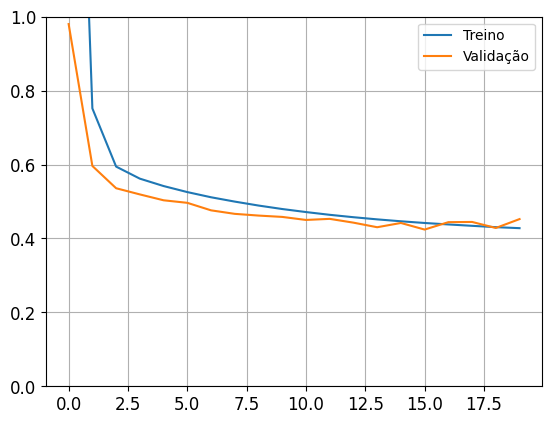

In [ ]:
#Ver a performance do treino quanto as partições de terino e teste
plt.plot(pd.DataFrame(history.history).loss, label = 'Treino' )
plt.plot(pd.DataFrame(history.history).val_loss, label = 'Validação' )
plt.grid(True)
plt.legend()
plt.gca().set_ylim(0, 1)
plt.show()

# Parte III: Criando uma RNA mais robusta e complexa

Nem todos os modelos de redes neurais são simplesmente sequenciais. Alguns podem ter topologias complexas. Alguns podem ter múltiplas entradas e/ou múltiplas saídas. Por exemplo, uma rede neural ampla e profunda conecta todas ou parte das entradas diretamente à camada de saída.

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
del model

In [ ]:
#Crinado uma nova rede de uma outra forma além do sequential
input_ = keras.layers.Input(shape=X_train.shape[1:])
hidden1 = keras.layers.Dense(30, activation="relu")(input_)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
# hidden3 = keras.layers.Dense(30, activation="relu")(hidden2)
# hidden4 = keras.layers.Dense(30, activation="relu")(hidden3)
concat = keras.layers.concatenate([input_, hidden2])
output = keras.layers.Dense(1)(concat)
model = keras.models.Model(inputs=[input_], outputs=[output])

In [ ]:
#Ver uma sumário da arquiteura da rede, incluindo a quantidade de parâmetros
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 8)]                  0         []                            
                                                                                                  
 dense_2 (Dense)             (None, 30)                   270       ['input_1[0][0]']             
                                                                                                  
 dense_3 (Dense)             (None, 30)                   930       ['dense_2[0][0]']             
                                                                                                  
 concatenate (Concatenate)   (None, 38)                   0         ['input_1[0][0]',             
                                                                     'dense_3[0][0]']         

In [ ]:
#Compilar a RNA e preparar para o treino
model.compile(loss="mean_squared_error", optimizer=keras.optimizers.SGD(learning_rate=1e-3))
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))
mse_test = model.evaluate(X_test, y_test)
y_pred = model.predict(X_new)

Epoch 1/20
363/363 [==============================] - 2s 3ms/step - loss: 1.7464 - val_loss: 5.2466
Epoch 2/20
363/363 [==============================] - 1s 4ms/step - loss: 0.7557 - val_loss: 0.8326
Epoch 3/20
363/363 [==============================] - 1s 4ms/step - loss: 0.6464 - val_loss: 0.7295
Epoch 4/20
363/363 [==============================] - 1s 2ms/step - loss: 0.6070 - val_loss: 0.5883
Epoch 5/20
363/363 [==============================] - 1s 2ms/step - loss: 0.5769 - val_loss: 0.5469
Epoch 6/20
363/363 [==============================] - 1s 2ms/step - loss: 0.5515 - val_loss: 0.5414
Epoch 7/20
363/363 [==============================] - 1s 3ms/step - loss: 0.5351 - val_loss: 0.5218
Epoch 8/20
363/363 [==============================] - 1s 2ms/step - loss: 0.5197 - val_loss: 0.5007
Epoch 9/20
363/363 [==============================] - 1s 2ms/step - loss: 0.5046 - val_loss: 0.4797
Epoch 10/20
363/363 [==============================] - 1s 3ms/step - loss: 0.4924 - val_loss: 0.4963

#Parte IV: Salvando e restaurando um modelo

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=[8]),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(1)
])

In [ ]:
model.compile(loss="mse", optimizer=keras.optimizers.SGD(learning_rate=1e-3))
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid))
mse_test = model.evaluate(X_test, y_test)

Epoch 1/10
363/363 [==============================] - 2s 3ms/step - loss: 1.9147 - val_loss: 1.5145
Epoch 2/10
363/363 [==============================] - 1s 3ms/step - loss: 0.7723 - val_loss: 0.6765
Epoch 3/10
363/363 [==============================] - 1s 2ms/step - loss: 0.6667 - val_loss: 0.6054
Epoch 4/10
363/363 [==============================] - 1s 2ms/step - loss: 0.6077 - val_loss: 0.5915
Epoch 5/10
363/363 [==============================] - 1s 3ms/step - loss: 0.5632 - val_loss: 0.5414
Epoch 6/10
363/363 [==============================] - 1s 3ms/step - loss: 0.5264 - val_loss: 0.4878
Epoch 7/10
363/363 [==============================] - 1s 3ms/step - loss: 0.4980 - val_loss: 0.4604
Epoch 8/10
363/363 [==============================] - 1s 3ms/step - loss: 0.4761 - val_loss: 0.4715
Epoch 9/10
363/363 [==============================] - 1s 2ms/step - loss: 0.4596 - val_loss: 0.4657
Epoch 10/10
162/162 [==============================] - 0s 2ms/step - loss: 0.4426


In [ ]:
#model.save("my_keras_model.keras")
model.save("my_keras_model", save_format="tf")

In [ ]:
#model = keras.models.load_model("my_keras_model.keras")
model = tf.keras.models.load_model("my_keras_model")

In [ ]:
#model.predict(X_new)
y_pred_main = model.predict(X_new)

1/1 [==============================] - 0s 101ms/step


In [ ]:
y_pred_main

array([[0.8133688],
       [1.752204 ],
       [3.5818036]], dtype=float32)

In [ ]:
#model.save_weights("my_keras.weights")
model.save_weights("my_weights")

In [ ]:
#model.load_weights("my_keras.weights.h5")
model.load_weights("my_weights")

#Parte V: Usando *Callbacks* durante o treinamento da RNA

In [ ]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=[8]),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(1)
])

In [ ]:
#Salvar o melhor modelo
model.compile(loss="mse", optimizer=keras.optimizers.SGD(learning_rate=1e-3))



In [ ]:
checkpoint_cb = keras.callbacks.ModelCheckpoint("my_keras_model", save_best_only=True)

history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid),
                    callbacks=[checkpoint_cb])

Epoch 1/10
363/363 [==============================] - 7s 12ms/step - loss: 1.8093 - val_loss: 0.7953
Epoch 2/10
363/363 [==============================] - 4s 10ms/step - loss: 0.7297 - val_loss: 0.7174
Epoch 3/10
363/363 [==============================] - 2s 7ms/step - loss: 0.6635 - val_loss: 0.7242
Epoch 4/10
363/363 [==============================] - 2s 5ms/step - loss: 0.6191 - val_loss: 0.6172
Epoch 5/10
363/363 [==============================] - 2s 5ms/step - loss: 0.5837 - val_loss: 0.5773
Epoch 6/10
363/363 [==============================] - 1s 4ms/step - loss: 0.5522 - val_loss: 0.5670
Epoch 7/10
363/363 [==============================] - 1s 4ms/step - loss: 0.5270 - val_loss: 0.5593
Epoch 8/10
363/363 [==============================] - 1s 4ms/step - loss: 0.5053 - val_loss: 0.5009
Epoch 9/10
363/363 [==============================] - 1s 4ms/step - loss: 0.4867 - val_loss: 0.4878
Epoch 10/10
363/363 [==============================] - 1s 2ms/step - loss: 0.4715 - val_loss: 0.48

In [ ]:
model = keras.models.load_model("my_keras_model") # rollback to best model

In [ ]:
mse_test = model.evaluate(X_test, y_test)

162/162 [==============================] - 0s 2ms/step - loss: 0.4710


In [ ]:
#Salvar os melhores pesos da RNA
model.compile(loss="mse", optimizer=keras.optimizers.SGD(learning_rate=1e-3))
early_stopping_cb = keras.callbacks.EarlyStopping(patience=10,
                                                  restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=100,
                    validation_data=(X_valid, y_valid),
                    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
363/363 [==============================] - 3s 6ms/step - loss: 0.4717 - val_loss: 0.4704
Epoch 2/100
363/363 [==============================] - 2s 5ms/step - loss: 0.4591 - val_loss: 0.4588
Epoch 3/100
363/363 [==============================] - 2s 5ms/step - loss: 0.4488 - val_loss: 0.4534
Epoch 4/100
363/363 [==============================] - 4s 10ms/step - loss: 0.4399 - val_loss: 0.4179
Epoch 5/100
363/363 [==============================] - 2s 6ms/step - loss: 0.4329 - val_loss: 0.4111
Epoch 6/100
363/363 [==============================] - 1s 4ms/step - loss: 0.4266 - val_loss: 0.4033
Epoch 7/100
363/363 [==============================] - 1s 4ms/step - loss: 0.4215 - val_loss: 0.3986
Epoch 8/100
363/363 [==============================] - 1s 4ms/step - loss: 0.4169 - val_loss: 0.3947
Epoch 9/100
363/363 [==============================] - 2s 4ms/step - loss: 0.4128 - val_loss: 0.3890
Epoch 10/100
363/363 [==============================] - 1s 4ms/step - loss: 0.4090 - val_l

In [ ]:
mse_test = model.evaluate(X_test, y_test)

162/162 [==============================] - 0s 2ms/step - loss: 0.3319


In [ ]:
class PrintValTrainRatioCallback(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs):
        print("\nval/train: {:.2f}".format(logs["val_loss"] / logs["loss"]))

In [ ]:
val_train_ratio_cb = PrintValTrainRatioCallback()
history = model.fit(X_train, y_train, epochs=1,
                    validation_data=(X_valid, y_valid),
                    callbacks=[val_train_ratio_cb])

359/363 [============================>.] - ETA: 0s - loss: 0.3253
val/train: 0.96
363/363 [==============================] - 1s 3ms/step - loss: 0.3261 - val_loss: 0.3144


#Parte VI: Ajuste fino dos hyperparâmetros

Neste seção, iremos usar o dataset Fashion MNIST outra vez

In [ ]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()

4422102/4422102 [==============================] - 1s 0us/step


In [ ]:
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

In [ ]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [ ]:
if "google.colab" in sys.modules:
    %pip install -q -U keras_tuner

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 3.3 MB/s eta 0:00:00


In [ ]:
import keras_tuner as kt

def build_model(hp):
    n_hidden = hp.Int("n_hidden", min_value=0, max_value=8, default=2)
    n_neurons = hp.Int("n_neurons", min_value=16, max_value=256)
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2,
                             sampling="log")
    optimizer = hp.Choice("optimizer", values=["sgd", "adam"])
    if optimizer == "sgd":
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Flatten())
    for _ in range(n_hidden):
        model.add(tf.keras.layers.Dense(n_neurons, activation="relu"))
    model.add(tf.keras.layers.Dense(10, activation="softmax"))
    model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
                  metrics=["accuracy"])
    return model

In [ ]:
random_search_tuner = kt.RandomSearch(
    build_model, objective="val_accuracy", max_trials=5, overwrite=True,
    directory="my_fashion_mnist", project_name="my_rnd_search", seed=42)
random_search_tuner.search(X_train, y_train, epochs=10,
                           validation_data=(X_valid, y_valid))

Trial 5 Complete [00h 01m 09s]
val_accuracy: 0.8446000218391418

Best val_accuracy So Far: 0.8623999953269958
Total elapsed time: 00h 07m 27s


In [ ]:
top3_models = random_search_tuner.get_best_models(num_models=3)
best_model = top3_models[0]

In [ ]:
top3_params = random_search_tuner.get_best_hyperparameters(num_trials=3)
top3_params[0].values  # best hyperparameter values

{'n_hidden': 7,
 'n_neurons': 100,
 'learning_rate': 0.0012482904754698163,
 'optimizer': 'sgd'}

In [ ]:
best_trial = random_search_tuner.oracle.get_best_trials(num_trials=1)[0]
best_trial.summary()

Trial 1 summary
Hyperparameters:
n_hidden: 7
n_neurons: 100
learning_rate: 0.0012482904754698163
optimizer: sgd
Score: 0.8623999953269958


In [ ]:
best_trial.metrics.get_last_value("val_accuracy")

0.8623999953269958

In [ ]:
best_model.fit(X_train_full, y_train_full, epochs=10)
test_loss, test_accuracy = best_model.evaluate(X_test, y_test)

Epoch 1/10
1875/1875 [==============================] - 10s 5ms/step - loss: 0.3376 - accuracy: 0.8752
Epoch 2/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.3263 - accuracy: 0.8803
Epoch 3/10
1875/1875 [==============================] - 8s 4ms/step - loss: 0.3171 - accuracy: 0.8833
Epoch 4/10
1875/1875 [==============================] - 8s 4ms/step - loss: 0.3094 - accuracy: 0.8860
Epoch 5/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.3031 - accuracy: 0.8878
Epoch 6/10
1875/1875 [==============================] - 8s 4ms/step - loss: 0.2948 - accuracy: 0.8903
Epoch 7/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.2888 - accuracy: 0.8934
Epoch 8/10
1875/1875 [==============================] - 8s 4ms/step - loss: 0.2831 - accuracy: 0.8956
Epoch 9/10
1875/1875 [==============================] - 8s 4ms/step - loss: 0.2772 - accuracy: 0.8969
Epoch 10/10
313/313 [==============================] - 1s 3ms/step - loss: 0.3901

In [ ]:
class MyClassificationHyperModel(kt.HyperModel):
    def build(self, hp):
        return build_model(hp)

    def fit(self, hp, model, X, y, **kwargs):
        if hp.Boolean("normalize"):
            norm_layer = tf.keras.layers.Normalization()
            X = norm_layer(X)
        return model.fit(X, y, **kwargs)

In [ ]:
hyperband_tuner = kt.Hyperband(
    MyClassificationHyperModel(), objective="val_accuracy", seed=42,
    max_epochs=10, factor=3, hyperband_iterations=2,
    overwrite=True, directory="my_fashion_mnist", project_name="hyperband")

In [ ]:
bayesian_opt_tuner = kt.BayesianOptimization(
    MyClassificationHyperModel(), objective="val_accuracy", seed=42,
    max_trials=10, alpha=1e-4, beta=2.6,
    overwrite=True, directory="my_fashion_mnist", project_name="bayesian_opt")
bayesian_opt_tuner.search(X_train, y_train, epochs=10,
                          validation_data=(X_valid, y_valid),
                          callbacks=[early_stopping_cb])

Trial 10 Complete [00h 01m 00s]
val_accuracy: 0.8411999940872192

Best val_accuracy So Far: 0.866599977016449
Total elapsed time: 00h 15m 08s


**Referências:**

[1] Conteúdo online modificado. GitHub do livro Hands-on Machine Learning with Scikit-Learn, Keras and TensorFlow. https://github.com/ageron/handson-ml3/blob/4e055a121da08e9c95c63df7645aabe83ff7ca80/10_neural_nets_with_keras.ipynb . Sob Licença Apache 2.0, January 2004, http://www.apache.org/licenses/ . Acesso em: 25/04/2024.

[2] GÉRON, Aurélien. Mãos à Obra: Aprendizado de Máquina com Scikit-Learn, Keras & TensorFlow: Conceitos, Ferramentas e Técnicas para a Construção de Sistemas Inteligentes. Editora Alta Books, 2021. E-book. ISBN 9786555208146. Disponível em: https://integrada.minhabiblioteca.com.br/#/books/9786555208146/. Acesso em: 25 fev. 2024.

[3] NETTO, Amilcar; MACIEL, Francisco. Python para data science e machine learning descomplicado. Rio de Janeiro: Alta Books, 2021. E-book. ISBN 9786555203172.

